# Working on clearing the data and merging

- find the .xlsx files
- delete duplicates
- saves the whole data

In [30]:
import pandas as pd

In [31]:
df = pd.DataFrame(pd.read_excel("../data/raw/Load of Polish Power System 2026-01-19 - 2026-02-01.xlsx"))
df.head()

,Date,OREB\n[Time unit from - to],Forecasted Total Load\n[MW],Actual Total Load\n[MW]
0,2026-01-19,00:00 - 00:15,17200,17909.328
1,2026-01-19,00:15 - 00:30,17050,17439.410
2,2026-01-19,00:30 - 00:45,16900,17515.727
3,2026-01-19,00:45 - 01:00,16800,17493.357
4,2026-01-19,01:00 - 01:15,16700,17276.377


In [32]:
import os

file_names_list = os.listdir("../data/raw")
file_list_sorted = sorted(file_names_list)

dfs_list = [
            pd.DataFrame(pd.read_excel(f"../data/raw/" + suffix))
            for suffix in file_list_sorted
          ]

all_data = pd.concat(dfs_list, axis=0, ignore_index=True)
all_data.columns = (all_data.columns.str.replace('\n', ' ', regex=False)
                    .str.strip())                    # removing the "\n"s from the titles

In [33]:
# drop duplicates
all_data.drop_duplicates(inplace=True)  # inplace, means to not create new dataframe

# saving merged the data to csv
all_data.to_csv("../data/processed/processed_data.csv", index=False)
# all_data.to_sql("../data/processed/processed_data.sql", index=False)
all_data.head()

,Date,OREB [Time unit from - to],Forecasted Total Load [MW],Actual Total Load [MW]
0,2026-01-19,00:00 - 00:15,17200,17909.328
1,2026-01-19,00:15 - 00:30,17050,17439.410
2,2026-01-19,00:30 - 00:45,16900,17515.727
3,2026-01-19,00:45 - 01:00,16800,17493.357
4,2026-01-19,01:00 - 01:15,16700,17276.377


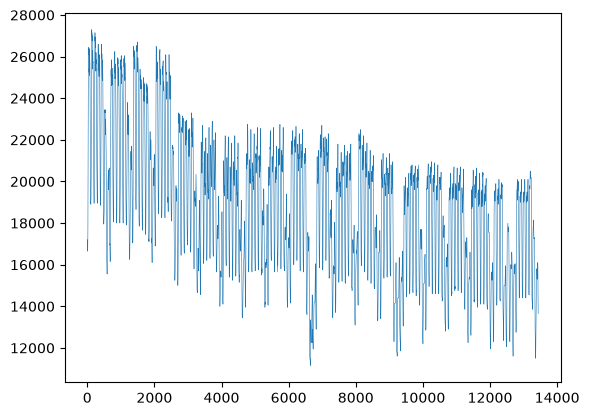

In [34]:
import matplotlib.pyplot as plt

plot = plt.plot(all_data['Forecasted Total Load [MW]'], linewidth=0.4)

In [35]:
all_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13436 entries, 0 to 13435
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        13436 non-null  str    
 1   OREB [Time unit from - to]  13436 non-null  str    
 2   Forecasted Total Load [MW]  13436 non-null  int64  
 3   Actual Total Load [MW]      13436 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 420.0 KB


In [36]:
all_data.head()

,Date,OREB [Time unit from - to],Forecasted Total Load [MW],Actual Total Load [MW]
0,2026-01-19,00:00 - 00:15,17200,17909.328
1,2026-01-19,00:15 - 00:30,17050,17439.410
2,2026-01-19,00:30 - 00:45,16900,17515.727
3,2026-01-19,00:45 - 01:00,16800,17493.357
4,2026-01-19,01:00 - 01:15,16700,17276.377


In [37]:
all_data["Time"] = all_data["OREB [Time unit from - to]"].str.split(" - ").str[0]   # taking the first part of the time and adding it to the columns
all_data.head()

,Date,OREB [Time unit from - to],Forecasted Total Load [MW],Actual Total Load [MW],Time
0,2026-01-19,00:00 - 00:15,17200,17909.328,00:00
1,2026-01-19,00:15 - 00:30,17050,17439.410,00:15
2,2026-01-19,00:30 - 00:45,16900,17515.727,00:30
3,2026-01-19,00:45 - 01:00,16800,17493.357,00:45
4,2026-01-19,01:00 - 01:15,16700,17276.377,01:00


In [38]:
all_data["Datetime"] = pd.to_datetime(all_data["Date"].astype(str) + " " + all_data["Time"].astype(str))    # creating a Datetime column with the date and time
all_data[["Date","Time", "Datetime"]].head()    # check it

,Date,Time,Datetime
0,2026-01-19,00:00,2026-01-19 00:00:00
1,2026-01-19,00:15,2026-01-19 00:15:00
2,2026-01-19,00:30,2026-01-19 00:30:00
3,2026-01-19,00:45,2026-01-19 00:45:00
4,2026-01-19,01:00,2026-01-19 01:00:00


In [39]:
all_data["Hour"] = all_data["Datetime"].dt.hour
all_data["Weekday"] = all_data["Datetime"].dt.day_name()
all_data["Month"] = all_data["Datetime"].dt.month
all_data[["Hour","Weekday", "Month"]].head()

,Hour,Weekday,Month
0,0,Monday,1
1,0,Monday,1
2,0,Monday,1
3,0,Monday,1
4,1,Monday,1
